In [1]:
from qiskit import QuantumCircuit,QuantumRegister,ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UGate
from math import pi
import random

/var/folders/st/7p6sfm791xddpk1by89b0kg40000gn/T/ipykernel_13241/177640489.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit,QuantumRegister,ClassicalRegister


In [2]:
qubit=QuantumRegister(1,"Q")
ebit0=QuantumRegister(1,"A")
ebit1=QuantumRegister(1,"B")
a= ClassicalRegister(1,"a")
b=ClassicalRegister(1,"b")
result=ClassicalRegister(1,"Result")

In [3]:
protocol=QuantumCircuit(qubit,ebit0,ebit1,a,b,result)

In [4]:
random.seed(5)
theta=random.random()*pi
phi=random.random()*2*pi
lam=random.random()*2*pi
test_gate=UGate(theta,phi,lam)
protocol.append(test_gate,qubit)
protocol.barrier()
protocol.h(ebit0)
protocol.cx(ebit0,ebit1)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [5]:
#alice's opeartions
protocol.cx(qubit,ebit0)
protocol.h(qubit)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [6]:
#alice measures

In [7]:
protocol.measure(ebit0,a)
protocol.measure(qubit,b)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

In [8]:
with protocol.if_test((a,1)):
  protocol.x(ebit1)
with protocol.if_test((b,1)):
     protocol.z(ebit1)

#verification

In [9]:
protocol.barrier()
protocol.append(test_gate.inverse(), ebit1)
protocol.measure(ebit1, result)

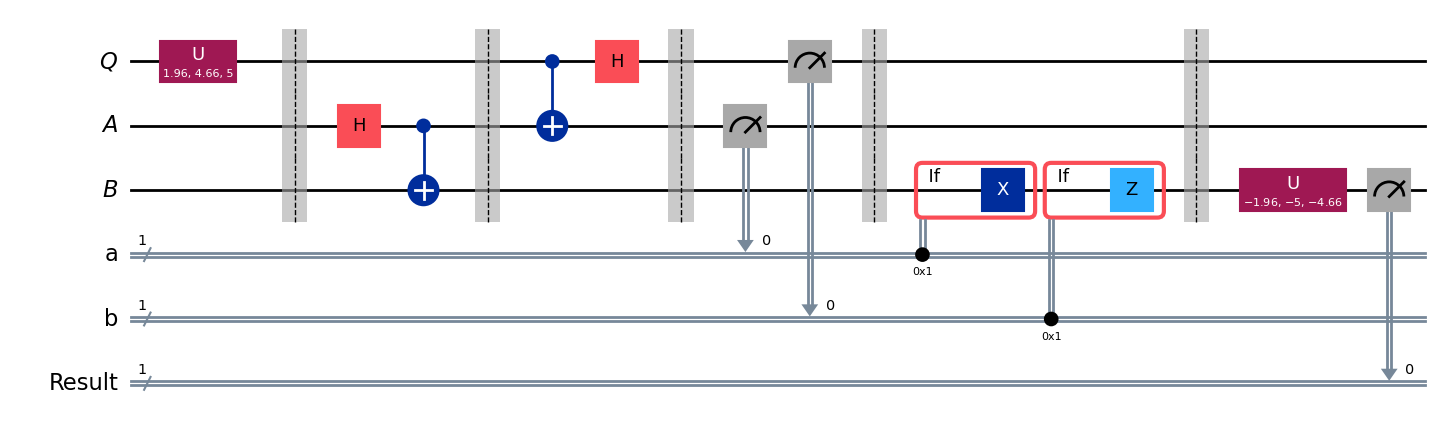

In [10]:
display(protocol.draw(output="mpl"))

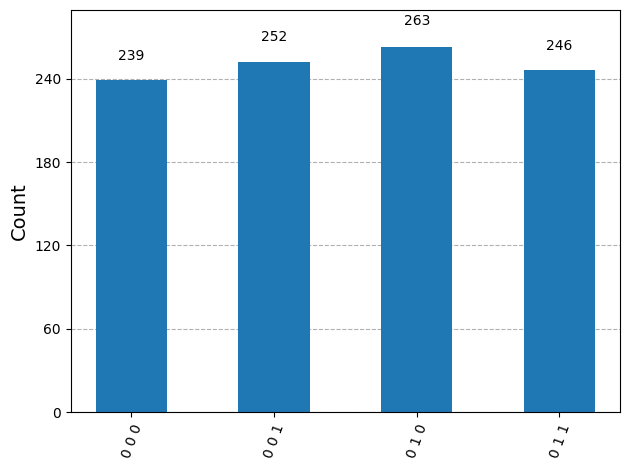

In [11]:
result_sim = AerSimulator().run(protocol, shots=1000).result()
statistics = result_sim.get_counts()
display(plot_histogram(statistics))

In [12]:
protocol.draw(output="mpl", filename="circuit.png")
plot_histogram(statistics, filename="histogram.png")